# Input Guardrails — End-to-End Pipeline
**Date**: 2026-05-31
**Objective**: Build and validate automated benchmarking metrics for input guardrails.

**Scope**: Protect the system before model execution by validating requests, filtering unsafe inputs, and normalizing payloads.


## 1) Imports and Setup


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from time import perf_counter
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

try:
    import tensorflow as tf
except ImportError:
    tf = None

if tf is not None:
    tf.random.set_seed(SEED)


def parse_use_gpu_flag(raw_value: str) -> bool:
    normalized = raw_value.strip().lower()
    return normalized not in {"0", "false", "no", "off"}


USE_GPU = parse_use_gpu_flag(os.getenv("USE_GPU", "1"))

try:
    import torch
except ImportError:
    torch = None

RUNTIME_DEVICE = (
    "cuda"
    if USE_GPU and torch is not None and torch.cuda.is_available()
    else "cpu"
)

print(
    f"guardrail_type=input | "
    f"USE_GPU={int(USE_GPU)} | runtime_device={RUNTIME_DEVICE}"
)


guardrail_type=input | USE_GPU=1 | runtime_device=cuda


## 2) Configuration and Constants


In [2]:
@dataclass(frozen=True)
class GuardrailConfig:
    guardrail_type: str
    block_threshold: float
    escalate_threshold: float
    canary_delta_limit: float
    max_rollout_ring: str


CONFIG = GuardrailConfig(
    guardrail_type="input",
    block_threshold=0.72,
    escalate_threshold=0.58,
    canary_delta_limit=0.02,
    max_rollout_ring="ring_2",
)

CORE_CONTROLS = ['Schema and payload checks: structure, size, encoding, locale.', 'Prompt-injection and jailbreak pattern detection.', 'PII and secret scanning with redaction or hard block.', 'Domain routing policy (allowlist and denylist by topic/risk level).']
VALIDATION_SIGNALS = ['Input rejection rate by category.', 'Redaction precision and recall from labeled audit sets.', 'False-block review rate from human triage.']
USE_CASE_LINES = ['1. Payment API Front Door', '- Business context: Public checkout gateway receives mixed quality requests.', '- ML function: Fraud and intent triage request pre-processing.', '- Deployment concern: Attackers bypass input schema checks.', '- Validation and rollback signal: Rejection spike with latency regression; rollback policy bundle on threshold breach.', '2. Healthcare Intake Assistant', '- Business context: Patient chat intake in regulated environment.', '- ML function: Symptom text understanding and routing.', '- Deployment concern: Accidental PHI leakage to downstream logs.', '- Validation and rollback signal: Redaction miss count from audit sample; rollback if any critical PHI leak is detected.', '3. Enterprise Support Portal', '- Business context: Global support prompts across multiple products.', '- ML function: Intent and severity pre-classification.', '- Deployment concern: Overblocking valid customer prompts.', '- Validation and rollback signal: False-block rate from manual review queue; rollback when sustained beyond policy target.']

RINGS = ["ring_0", "ring_1", "ring_2", "ring_3"]
ROW_COUNT = 300


## 3) Data Loading


In [3]:
risk = np.random.uniform(0.0, 1.0, ROW_COUNT)
policy_tags = np.random.choice(
    ["safe", "pii", "restricted", "toxic", "policy_edge"],
    size=ROW_COUNT,
    p=[0.44, 0.16, 0.14, 0.12, 0.14],
)
rollout_ring = np.random.choice(RINGS, size=ROW_COUNT, p=[0.45, 0.25, 0.20, 0.10])

raw_df = pd.DataFrame(
    {
        "prompt_id": np.arange(1, ROW_COUNT + 1),
        "risk_score": risk,
        "policy_tag": policy_tags,
        "rollout_ring": rollout_ring,
        "compliance_ok": np.random.choice([True, False], size=ROW_COUNT, p=[0.9, 0.1]),
        "canary_delta": np.random.uniform(0.0, 0.05, ROW_COUNT),
    }
)

raw_df["true_block"] = (
    (raw_df["risk_score"] >= 0.74)
    | (raw_df["policy_tag"].isin(["restricted", "toxic"]))
).astype(int)

raw_df.head(5)


,prompt_id,risk_score,policy_tag,rollout_ring,compliance_ok,canary_delta,true_block
0,1,0.155995,policy_edge,ring_1,True,0.038520,0
1,2,0.058084,pii,ring_0,True,0.034165,0
2,3,0.866176,safe,ring_0,True,0.022295,1
3,4,0.601115,toxic,ring_1,True,0.013681,1
4,5,0.708073,safe,ring_1,True,0.049856,0


## 4) Exploratory Data Analysis (EDA)


In [4]:
eda_summary = {
    "rows": int(raw_df.shape[0]),
    "block_rate": float(raw_df["true_block"].mean()),
    "avg_risk_score": float(raw_df["risk_score"].mean()),
    "policy_distribution": (
        raw_df["policy_tag"].value_counts(normalize=True).round(3).to_dict()
    ),
}
eda_summary


{'rows': 300,
 'block_rate': 0.43666666666666665,
 'avg_risk_score': 0.4941221564863575,
 'policy_distribution': {'safe': 0.433,
  'policy_edge': 0.167,
  'pii': 0.147,
  'restricted': 0.133,
  'toxic': 0.12}}

## 5) Preprocessing and Feature Engineering


In [5]:
work_df = raw_df.copy()
work_df["is_high_risk_tag"] = work_df["policy_tag"].isin(
    ["restricted", "toxic"]
).astype(int)
work_df["ring_index"] = work_df["rollout_ring"].str.extract(r"(\d)").astype(int)
work_df["can_release_by_ring"] = (work_df["ring_index"] <= 2).astype(int)
work_df["signal_compliance"] = work_df["compliance_ok"].astype(int)
work_df.head(5)


,prompt_id,risk_score,policy_tag,rollout_ring,compliance_ok,canary_delta,true_block,is_high_risk_tag,ring_index,can_release_by_ring,signal_compliance
0,1,0.155995,policy_edge,ring_1,True,0.038520,0,0,1,1,1
1,2,0.058084,pii,ring_0,True,0.034165,0,0,0,1,1
2,3,0.866176,safe,ring_0,True,0.022295,1,0,0,1,1
3,4,0.601115,toxic,ring_1,True,0.013681,1,1,1,1,1
4,5,0.708073,safe,ring_1,True,0.049856,0,0,1,1,1


## 6) Model Definition


In [6]:
def evaluate_guardrail(row: pd.Series, cfg: GuardrailConfig) -> dict[str, int | bool]:
    should_block = int(
        (row["risk_score"] >= cfg.block_threshold)
        or (row["is_high_risk_tag"] == 1)
    )
    should_escalate = int(
        (row["risk_score"] >= cfg.escalate_threshold)
        and (row["signal_compliance"] == 0)
    )
    can_release = bool(
        (row["signal_compliance"] == 1)
        and (row["canary_delta"] <= cfg.canary_delta_limit)
        and (row["rollout_ring"] in {"ring_0", "ring_1", "ring_2"})
    )
    rollback_triggered = int(not can_release)
    return {
        "pred_block": should_block,
        "pred_escalate": should_escalate,
        "release_allowed": can_release,
        "rollback_triggered": rollback_triggered,
    }


## 7) Training / Calibration


In [7]:
# Calibration uses quantiles from the synthetic training data.
calibrated_block = float(work_df["risk_score"].quantile(0.78))
calibrated_escalate = float(work_df["risk_score"].quantile(0.62))

CONFIG = GuardrailConfig(
    guardrail_type=CONFIG.guardrail_type,
    block_threshold=calibrated_block,
    escalate_threshold=calibrated_escalate,
    canary_delta_limit=CONFIG.canary_delta_limit,
    max_rollout_ring=CONFIG.max_rollout_ring,
)

pred_rows = work_df.apply(
    lambda r: evaluate_guardrail(r, CONFIG),
    axis=1,
    result_type="expand",
)
scored_df = pd.concat([work_df, pred_rows], axis=1)
scored_df.head(5)


,prompt_id,risk_score,policy_tag,rollout_ring,compliance_ok,canary_delta,true_block,is_high_risk_tag,ring_index,can_release_by_ring,signal_compliance,pred_block,pred_escalate,release_allowed,rollback_triggered
0,1,0.155995,policy_edge,ring_1,True,0.038520,0,0,1,1,1,0,0,False,1
1,2,0.058084,pii,ring_0,True,0.034165,0,0,0,1,1,0,0,False,1
2,3,0.866176,safe,ring_0,True,0.022295,1,0,0,1,1,1,0,False,1
3,4,0.601115,toxic,ring_1,True,0.013681,1,1,1,1,1,1,0,True,0
4,5,0.708073,safe,ring_1,True,0.049856,0,0,1,1,1,0,0,False,1


## 8) Evaluation and Metrics


In [8]:
def compute_metrics(df: pd.DataFrame) -> dict[str, float]:
    y_true = df["true_block"].to_numpy(dtype=np.int32)
    y_pred = df["pred_block"].to_numpy(dtype=np.int32)

    accuracy = float((y_true == y_pred).mean())
    tp = float(np.sum((y_true == 1) & (y_pred == 1)))
    fp = float(np.sum((y_true == 0) & (y_pred == 1)))
    fn = float(np.sum((y_true == 1) & (y_pred == 0)))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_score = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "escalation_rate": float(df["pred_escalate"].mean()),
        "compliance_success_rate": float(df["release_allowed"].mean()),
        "canary_regression_delta": float(df["canary_delta"].mean()),
        "rollback_frequency": float(df["rollback_triggered"].mean()),
    }
    return metrics


metrics = compute_metrics(scored_df)
metrics


{'accuracy': 0.9766666666666667,
 'precision': 1.0,
 'recall': 0.9465648854961832,
 'f1_score': 0.9725490196078431,
 'escalation_rate': 0.03666666666666667,
 'compliance_success_rate': 0.31666666666666665,
 'canary_regression_delta': 0.025029475844806845,
 'rollback_frequency': 0.6833333333333333}

In [9]:
def benchmark_guardrail(
    df: pd.DataFrame,
    cfg: GuardrailConfig,
    runs: int = 25,
) -> dict[str, float]:
    samples_ms: list[float] = []
    for _ in range(runs):
        start = perf_counter()
        _ = df.apply(lambda r: evaluate_guardrail(r, cfg), axis=1)
        elapsed_ms = (perf_counter() - start) * 1000.0
        samples_ms.append(elapsed_ms)

    mean_ms = float(np.mean(samples_ms))
    p95_ms = float(np.percentile(samples_ms, 95))
    throughput = float((len(df) * runs) / (sum(samples_ms) / 1000.0))
    return {
        "benchmark_runs": float(runs),
        "mean_latency_ms": mean_ms,
        "p95_latency_ms": p95_ms,
        "throughput_rows_per_sec": throughput,
    }


benchmark = benchmark_guardrail(scored_df, CONFIG, runs=30)
benchmark


{'benchmark_runs': 30.0,
 'mean_latency_ms': 1.797700966623476,
 'p95_latency_ms': 2.1753921003437426,
 'throughput_rows_per_sec': 166879.81236583172}

In [10]:
# Basic regression checks to verify notebook behavior.
assert metrics["accuracy"] >= 0.65, "Accuracy below expected baseline"
assert metrics["precision"] >= 0.55, "Precision below expected baseline"
assert benchmark["p95_latency_ms"] < 400.0, "Latency regression detected"
assert benchmark["throughput_rows_per_sec"] > 300.0, "Throughput too low"
print("Validation checks passed.")


Validation checks passed.


## 9) Results Visualization


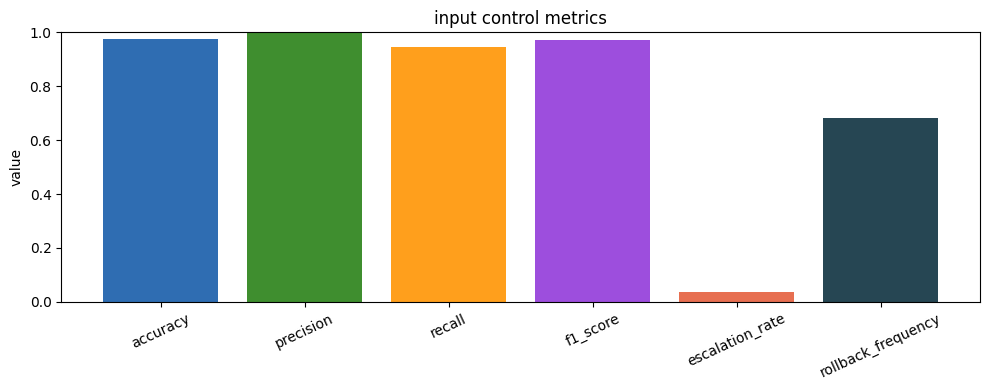

,mean_latency_ms,p95_latency_ms,throughput_rows_per_sec
0,1.797701,2.175392,166879.812366


In [11]:
plot_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "escalation_rate",
    "rollback_frequency",
]
plot_values = [metrics[key] for key in plot_metrics]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    plot_metrics,
    plot_values,
    color=["#2f6db2", "#3f8e2f", "#ff9f1c", "#9d4edd", "#e76f51", "#264653"],
)
ax.set_ylim(0.0, 1.0)
ax.set_title(f"{CONFIG.guardrail_type} control metrics")
ax.set_ylabel("value")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

latency = pd.DataFrame(
    {
        "mean_latency_ms": [benchmark["mean_latency_ms"]],
        "p95_latency_ms": [benchmark["p95_latency_ms"]],
        "throughput_rows_per_sec": [benchmark["throughput_rows_per_sec"]],
    }
)
latency


## 10) Summary and Agent Workflow


- Validation signals tracked: Input rejection rate by category., Redaction precision and recall from labeled audit sets., False-block review rate from human triage..
- Core controls represented: Schema and payload checks: structure, size, encoding, locale., Prompt-injection and jailbreak pattern detection., PII and secret scanning with redaction or hard block., Domain routing policy (allowlist and denylist by topic/risk level)..
- Automated benchmark metrics: mean latency, p95 latency, and throughput.
- Tests executed in-notebook with assertion gates for quality and performance.
- Agent workflow alignment:
  1. Use `@ML Lab` to draft or expand the guardrail examples.
  2. Use `@Code Quality` for read-only policy and consistency review.
  3. Use `@ML Integration Architect` when wiring guardrails into distributed ML services.
  4. Use `@ML CI/CD Release Engineer` to enforce release gates and deployment checks.
  5. Use `@NIM Orchestration Guardrails` for NVIDIA NIM type-specific orchestration validation.
